# Used Libraries

In [1]:
# Import pandas for tabular data manipulation and analysis.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

# Import Data

In [2]:
# Load all datasets
customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
order_payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

# Cleaning

## <span style="color: #5DADE2;">Orders</span>

In [3]:
# Inspect the basic structure of the orders dataset.
display(orders.shape)
display(orders.head())
display(orders.info())

(99441, 8)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


None

In [4]:
# Check for completely duplicated rows
orders.duplicated().sum()

np.int64(0)

In [5]:
# Check for duplicated order IDs
orders["order_id"].duplicated().sum()

np.int64(0)

In [6]:
# Check the number of orders for each order status
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [7]:
# Check missing values in date columns for each order status
orders.groupby("order_status")[
    [
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date"
    ]
].apply(lambda x: x.isna().sum())

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,0,2,2
canceled,141,550,619
created,5,5,5
delivered,14,2,8
invoiced,0,314,314
processing,0,301,301
shipped,0,0,1107
unavailable,0,609,609


In [8]:
# Inspect delivered orders with missing date values
delivered_missing_dates = orders[
    (orders["order_status"] == "delivered") &
    (
        orders["order_approved_at"].isna() |
        orders["order_delivered_carrier_date"].isna() |
        orders["order_delivered_customer_date"].isna()
    )
]

delivered_missing_dates

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaN,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17 00:00:00
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaN,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21 00:00:00
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaN,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaN,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31 00:00:00
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaN,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20 00:00:00
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaN,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01 00:00:00
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaN,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27 00:00:00
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaN,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22 00:00:00


In [9]:
# Inspect approved orders with delivery dates
approved_orders = orders[
    (orders["order_status"] == "approved") &
    (
        orders["order_delivered_carrier_date"].notna() |
        orders["order_delivered_customer_date"].notna()
    )
]

approved_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


In [10]:
# Convert order date columns from object to datetime
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [11]:
# Verify the data types of the date columns
orders[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [12]:
# Check for orders approved before they were purchased
invalid_approval = orders[
    orders["order_approved_at"].notna() &
    (orders["order_approved_at"] < orders["order_purchase_timestamp"])
]

invalid_approval.shape

(0, 8)

In [13]:
# Check for orders delivered to the carrier before they were approved
invalid_carrier = orders[
    orders["order_approved_at"].notna() &
    orders["order_delivered_carrier_date"].notna() &
    (orders["order_delivered_carrier_date"] < orders["order_approved_at"])
]

invalid_carrier.shape

(1359, 8)

In [14]:
# Inspect orders where the carrier delivery date is earlier than the approval date
invalid_carrier[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date"
    ]
].sort_values("order_approved_at").head(20)

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date
25411,6b80bb20190715d71c43efff617bd659,delivered,2017-02-19 01:15:03,2017-03-01 10:51:46,2017-02-22 16:05:29
94980,2d0d4075ded592212bcd5e5bc561b406,delivered,2017-04-26 12:22:32,2017-04-26 13:06:25,2017-04-26 13:01:25
4466,69a236fbbc4a603ebfa4468a3bdcb140,delivered,2017-04-25 01:46:02,2017-04-27 10:32:00,2017-04-26 09:11:44
63934,a60d571514c73cfc7655d67c75ed82c7,delivered,2017-04-25 09:50:01,2017-04-27 10:32:03,2017-04-27 07:18:06
71317,af2adc7e31b52bdfe068cf60426b54b2,delivered,2017-04-24 09:14:06,2017-04-27 10:32:39,2017-04-26 18:47:58
66029,cc460ac4435835dfdda5526dfe84f01f,delivered,2017-04-25 10:10:12,2017-04-27 10:32:44,2017-04-26 09:16:59
41421,1bab77281b20f4719d0a9f87f2282fde,delivered,2017-04-24 22:25:28,2017-04-27 10:33:13,2017-04-27 07:42:03
88196,c72e93d7e98b14432271347cec69043b,delivered,2017-04-25 22:48:07,2017-04-27 13:32:48,2017-04-27 08:04:28
59468,3464107c541f0583d599cc7d335cb9c7,delivered,2017-04-25 23:34:07,2017-04-27 13:33:18,2017-04-27 11:53:10
42182,294a3f0960f3588f7b1597da079f590e,delivered,2017-04-25 22:15:42,2017-04-27 13:33:23,2017-04-27 07:18:06


In [15]:
# Calculate the difference between approval and carrier delivery in days
invalid_carrier["approval_to_carrier_days"] = (
    invalid_carrier["order_delivered_carrier_date"]
    - invalid_carrier["order_approved_at"]
).dt.total_seconds() / (24 * 3600)

invalid_carrier.groupby("order_status")["approval_to_carrier_days"].describe()

C:\Users\thest\AppData\Local\Temp\ipykernel_30920\758241293.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  invalid_carrier["approval_to_carrier_days"] = (


,count,mean,std,min,25%,50%,75%,max
order_status,,,,,,,,
delivered,1350.0,-1.029290,4.818968,-171.219005,-1.081389,-0.714988,-0.058869,-0.000243
shipped,9.0,-1.337684,1.539714,-4.096840,-1.093681,-1.059988,-0.183438,-0.053056


### Data Quality Issue: Approval and Carrier Delivery Dates

We found 1,359 orders where the `order_delivered_carrier_date` occurs before the `order_approved_at` timestamp.

- 1,350 orders have a `delivered` status.
- 9 orders have a `shipped` status.
- The time difference is not limited to a few minutes; some records have large differences.

This indicates a chronological inconsistency between the two timestamps.

**Decision:**  
We will not modify or delete these records at this stage. We will first complete all date-related quality checks in the `orders` file and determine whether this issue is related to other data quality issues.

The final treatment (fix, remove, or retain with a documented limitation) will be decided during the final cleaning stage.

In [16]:
# Check for orders delivered to the customer before they were handed to the carrier
invalid_customer_delivery = orders[
    orders["order_delivered_carrier_date"].notna() &
    orders["order_delivered_customer_date"].notna() &
    (orders["order_delivered_customer_date"] < orders["order_delivered_carrier_date"])
]

invalid_customer_delivery.shape

(23, 8)

In [17]:
# Inspect orders where the customer delivery date is earlier than the carrier delivery date
invalid_customer_delivery[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].sort_values("order_delivered_customer_date")

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
49933,76458889992169d3135b264dc13aec67,delivered,2016-10-07 10:05:16,2016-10-07 11:24:43,2016-10-26 11:43:06,2016-10-20 18:03:17,2016-11-29
71227,19feb5627c41ea1b36a8e50a469b3644,delivered,2016-10-07 17:09:56,2016-10-07 17:32:09,2016-10-26 11:42:05,2016-10-20 19:07:54,2016-12-01
95634,f688669f48063536e082bb32d634cd46,delivered,2016-10-07 10:28:56,2016-10-11 04:56:13,2016-10-21 18:02:40,2016-10-20 20:33:27,2016-11-29
21338,8c78d01de3a9009e23d6877a7cc9be20,delivered,2016-10-08 15:36:50,2016-10-08 18:13:44,2016-10-26 11:41:53,2016-10-25 17:51:46,2016-11-30
74967,d5558a097766363b8e76b38c43332e8a,delivered,2017-02-04 19:01:33,2017-02-04 19:31:12,2017-02-15 08:55:26,2017-02-10 07:58:32,2017-03-01
34939,c1e2bf2b7dd3309f2f5356c6b63968fa,delivered,2017-02-10 10:19:10,2017-02-10 10:30:13,2017-03-02 17:34:26,2017-02-14 15:15:57,2017-03-15
41636,b866af202be0692766081310cd4085e1,delivered,2017-01-27 14:59:17,2017-01-27 15:30:46,2017-02-20 02:32:08,2017-02-15 03:53:46,2017-04-17
76120,771c4f1f521f462e4b95619e648aaeab,delivered,2017-03-22 20:15:15,2017-03-22 20:15:15,2017-03-30 13:14:34,2017-03-28 17:28:32,2017-04-12
45302,29941903985f944b0ffc49c479c1547d,delivered,2017-05-29 16:16:50,2017-05-29 16:25:16,2017-06-09 15:07:29,2017-06-02 11:09:16,2017-06-23
22520,b27af682321527a6349f1761eb3f360c,delivered,2017-06-14 20:17:04,2017-06-14 20:30:08,2017-06-27 14:51:54,2017-06-26 15:45:35,2017-07-14


### Data Quality Issue: Customer Delivery Before Carrier Delivery

We found 23 delivered orders where the recorded
`order_delivered_customer_date` occurs before the
`order_delivered_carrier_date`.

This creates a chronological inconsistency because the customer
delivery date is expected to occur after the carrier delivery date.

The affected records show different time differences, ranging
from small differences to several days.

**Decision:**  
The affected orders will not be deleted or have their timestamps
modified at this stage. We will complete all date-related quality
checks first and then determine the appropriate treatment during
the final cleaning stage.

In [18]:
# Check for orders delivered to the customer before the order was purchased
invalid_customer_purchase = orders[
    orders["order_purchase_timestamp"].notna() &
    orders["order_delivered_customer_date"].notna() &
    (orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"])
]

invalid_customer_purchase.shape

(0, 8)

In [19]:
# Check how many delivered orders arrived after the estimated delivery date
late_deliveries = orders[
    orders["order_delivered_customer_date"].notna() &
    (orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"])
]

late_deliveries.shape

(7827, 8)

### Delivery Date Check: Actual vs Estimated Delivery

We found 7,827 orders where the actual customer delivery date
occurred after the estimated delivery date.

This is not considered a data quality issue because the
`order_estimated_delivery_date` represents an expected delivery
date, while `order_delivered_customer_date` represents the actual
delivery date.

**Result:**  
The records will be retained without modification.

This difference can be used later in EDA to analyze delivery delays.

In [20]:
# Check for orders where the estimated delivery date is before the purchase date
invalid_estimated_delivery = orders[
    orders["order_estimated_delivery_date"] <
    orders["order_purchase_timestamp"]
]

invalid_estimated_delivery.shape

(0, 8)

In [21]:
# Collect order IDs with inconsistent date relationships

invalid_approval_carrier = orders[
    orders["order_approved_at"].notna() &
    orders["order_delivered_carrier_date"].notna() &
    (
        orders["order_approved_at"] >
        orders["order_delivered_carrier_date"]
    )
]

invalid_carrier_customer = orders[
    orders["order_delivered_carrier_date"].notna() &
    orders["order_delivered_customer_date"].notna() &
    (
        orders["order_delivered_customer_date"] <
        orders["order_delivered_carrier_date"]
    )
]

# Combine all affected order IDs
invalid_order_ids = set(
    invalid_approval_carrier["order_id"]
).union(
    invalid_carrier_customer["order_id"]
)

print("Invalid order IDs:", len(invalid_order_ids))

Invalid order IDs: 1382


In [22]:
# Remove invalid orders from all datasets containing order_id

orders = orders[
    ~orders["order_id"].isin(invalid_order_ids)
].copy()

order_items = order_items[
    ~order_items["order_id"].isin(invalid_order_ids)
].copy()

reviews = reviews[
    ~reviews["order_id"].isin(invalid_order_ids)
].copy()

In [23]:
# Check how many rows will be removed from each dataset

print("Orders:", orders["order_id"].isin(invalid_order_ids).sum())
print("Order items:", order_items["order_id"].isin(invalid_order_ids).sum())
print("Reviews:", reviews["order_id"].isin(invalid_order_ids).sum())

Orders: 0
Order items: 0
Reviews: 0


In [24]:
# Analyze review availability across different order statuses

order_review_status = orders.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

order_review_status["has_review"] = (
    order_review_status["review_score"].notna()
)

review_by_status = (
    order_review_status
    .groupby("order_status")["has_review"]
    .agg(
        total_orders="count",
        orders_with_review="sum"
    )
)

review_by_status["orders_without_review"] = (
    review_by_status["total_orders"]
    - review_by_status["orders_with_review"]
)

review_by_status["review_rate_%"] = (
    review_by_status["orders_with_review"]
    / review_by_status["total_orders"]
    * 100
).round(2)

display(review_by_status)

,total_orders,orders_with_review,orders_without_review,review_rate_%
order_status,,,,
approved,2,2,0,100.00
canceled,629,609,20,96.82
created,5,3,2,60.00
delivered,95632,94993,639,99.33
invoiced,318,313,5,98.43
processing,302,296,6,98.01
shipped,1108,1035,73,93.41
unavailable,611,597,14,97.71


## <span style="color: #5DADE2;">Order Items</span>

In [25]:
# Inspect the basic structure of the order-items dataset.
display(order_items.shape)
display(order_items.head())
display(order_items.info())

(111049, 7)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


<class 'pandas.core.frame.DataFrame'>
Index: 111049 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             111049 non-null  object 
 1   order_item_id        111049 non-null  int64  
 2   product_id           111049 non-null  object 
 3   seller_id            111049 non-null  object 
 4   shipping_limit_date  111049 non-null  object 
 5   price                111049 non-null  float64
 6   freight_value        111049 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.8+ MB


None

In [26]:
# Check for duplicated order-item combinations
orders_items_duplicates = order_items.duplicated(
    subset=["order_id", "order_item_id"]
).sum()

orders_items_duplicates

np.int64(0)

In [27]:
# Check the range of order_item_id values
order_items["order_item_id"].agg(["min", "max"])

min     1
max    21
Name: order_item_id, dtype: int64

In [28]:
# Check for invalid order_item_id values
(order_items["order_item_id"] <= 0).sum()

np.int64(0)

In [29]:
# Check the basic statistics of price and freight value
order_items[["price", "freight_value"]].describe()

,price,freight_value
count,111049.000000,111049.000000
mean,120.800954,19.984038
std,183.988693,15.816972
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.250000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [30]:
# Convert shipping_limit_date to datetime
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"]
)

In [31]:
# Map each order to its purchase timestamp
purchase_dates = orders.set_index("order_id")["order_purchase_timestamp"]

# Compare shipping limit date with the corresponding purchase date
shipping_before_purchase = order_items[
    order_items["shipping_limit_date"] <
    order_items["order_id"].map(purchase_dates)
]

shipping_before_purchase.shape

(0, 7)

In [32]:
# Check data types
order_items.dtypes

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

## <span style="color: #5DADE2;">Order Reviews</span>

In [33]:
# Inspect the basic structure of the reviews dataset
display(reviews.shape)
display(reviews.head())
display(reviews.info())

(97848, 7)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


<class 'pandas.core.frame.DataFrame'>
Index: 97848 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                97848 non-null  object
 1   order_id                 97848 non-null  object
 2   review_score             97848 non-null  int64 
 3   review_comment_title     11140 non-null  object
 4   review_comment_message   40444 non-null  object
 5   review_creation_date     97848 non-null  object
 6   review_answer_timestamp  97848 non-null  object
dtypes: int64(1), object(6)
memory usage: 6.0+ MB


None

In [34]:
# Check for multiple reviews for the same order
display(reviews["order_id"].duplicated().sum())

np.int64(548)

In [35]:
# Check how many reviews each order has
display(reviews.groupby("order_id").size().value_counts())

1    96756
2      540
3        4
Name: count, dtype: int64

In [36]:
# Inspect orders with multiple reviews
duplicate_reviews = (
    reviews[reviews["order_id"].duplicated(keep=False)]
    .sort_values(["order_id", "review_creation_date"])
)

display(
    duplicate_reviews[
        [
            "order_id",
            "review_score",
            "review_creation_date",
            "review_answer_timestamp"
        ]
    ].head(20)
)

,order_id,review_score,review_creation_date,review_answer_timestamp
22423,0035246a40f520710769010f752e7507,5,2017-08-25 00:00:00,2017-08-29 21:45:57
25612,0035246a40f520710769010f752e7507,5,2017-08-29 00:00:00,2017-08-30 01:59:12
22779,013056cfe49763c6f66bda03396c5ee3,5,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,013056cfe49763c6f66bda03396c5ee3,4,2018-03-04 00:00:00,2018-03-05 17:02:00
854,0176a6846bcb3b0d3aa3116a9a768597,5,2017-12-30 00:00:00,2018-01-02 10:54:06
83224,0176a6846bcb3b0d3aa3116a9a768597,5,2017-12-30 00:00:00,2018-01-02 10:54:47
89888,02355020fd0a40a0d56df9f6ff060413,3,2018-03-21 00:00:00,2018-03-22 01:32:08
17582,02355020fd0a40a0d56df9f6ff060413,1,2018-03-29 00:00:00,2018-03-30 03:16:19
37911,029863af4b968de1e5d6a82782e662f5,5,2017-07-14 00:00:00,2017-07-17 13:58:06
55137,029863af4b968de1e5d6a82782e662f5,4,2017-07-19 00:00:00,2017-07-20 12:06:11


### Multiple Reviews per Order

Some orders have more than one review, with different `review_id` values
and, in some cases, different review scores and creation dates.

Therefore, duplicated `order_id` values are not considered duplicate records
and will not be removed during cleaning.

In [37]:
# Check the distribution and range of review scores
display(reviews["review_score"].value_counts().sort_index())
display(reviews["review_score"].describe())

review_score
1    11318
2     3111
3     8097
4    18868
5    56454
Name: count, dtype: int64

count    97848.000000
mean         4.083609
std          1.349420
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

In [38]:
# Convert review date columns to datetime

date_columns = [
    "review_creation_date",
    "review_answer_timestamp"
]

reviews[date_columns] = reviews[date_columns].apply(pd.to_datetime)

reviews[date_columns].dtypes

review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object

In [39]:
# Check the chronological relationship between review creation and answer timestamps

invalid_review_dates = reviews[
    reviews["review_answer_timestamp"] < reviews["review_creation_date"]
]

display(invalid_review_dates.shape)

(0, 7)

## <span style="color: #5DADE2;">Products</span>

In [40]:
# Inspect the basic structure of the products dataset
display(products.shape)
display(products.head())
display(products.info())

(32951, 9)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


None

In [41]:
# Inspect missing values in products
display(products.isna().sum())

# Check whether missing values are concentrated in the same products
display(
    products[
        products[[
            "product_category_name",
            "product_name_lenght",
            "product_description_lenght",
            "product_photos_qty"
        ]].isna().all(axis=1)
    ].shape
)

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

(610, 9)

In [42]:
# Check whether the 610 missing values belong to the same products

missing_product_info = products[
    products[
        [
            "product_category_name",
            "product_name_lenght",
            "product_description_lenght",
            "product_photos_qty"
        ]
    ].isna().all(axis=1)
]

display(missing_product_info.shape)

(610, 9)

In [43]:
# Check whether missing weight and dimensions belong to the same products

missing_dimensions = products[
    products[
        [
            "product_weight_g",
            "product_length_cm",
            "product_height_cm",
            "product_width_cm"
        ]
    ].isna().all(axis=1)
]

display(missing_dimensions.shape)
display(missing_dimensions[["product_id"]])

(2, 9)

,product_id
8578,09ff539a621711667c43eba6a3bd8466
18851,5eb564652db742ff8f28759cd8d2652a


In [44]:
# Count distinct orders that contain the 2 products with missing physical attributes

missing_product_ids = missing_dimensions["product_id"]

num_orders = order_items[
    order_items["product_id"].isin(missing_product_ids)
]["order_id"].nunique()

print("Number of distinct orders containing the 2 products with missing physical attributes:", num_orders)

Number of distinct orders containing the 2 products with missing physical attributes: 16


In [45]:
# Inspect descriptive statistics for numerical product attributes

display(products.describe())

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


## <span style="color: #5DADE2;">Customers</span>

In [46]:
# Inspect the basic structure of the customers dataset
display(customers.shape)
display(customers.head())
display(customers.info())

(99441, 5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


None

In [47]:
# Check the uniqueness of customer IDs

print("Unique customer_id values:", customers["customer_id"].nunique())
print("Unique customer_unique_id values:", customers["customer_unique_id"].nunique())

Unique customer_id values: 99441
Unique customer_unique_id values: 96096


In [48]:
# Inspect unique customer ZIP code prefixes
print("Number of unique customer ZIP code prefixes:",
      customers["customer_zip_code_prefix"].nunique())

display(customers["customer_zip_code_prefix"].unique())

# Inspect the range of customer ZIP code prefixes
print("Minimum ZIP code prefix:", customers["customer_zip_code_prefix"].min())
print("Maximum ZIP code prefix:", customers["customer_zip_code_prefix"].max())

Number of unique customer ZIP code prefixes: 14994


array([14409,  9790,  1151, ...,  5538, 74980, 99043], shape=(14994,))

Minimum ZIP code prefix: 1003
Maximum ZIP code prefix: 99990


In [49]:
# Check the number of unique customer city names

print("Number of unique customer city names:",
      customers["customer_city"].nunique())

Number of unique customer city names: 4119


In [50]:
# Check for city names with different capitalization

city_case_check = (
    customers.assign(city_lower=customers["customer_city"].str.lower())
    .groupby("city_lower")["customer_city"]
    .nunique()
)

print("Number of city names with different representations:",
      (city_case_check > 1).sum())

Number of city names with different representations: 0


## <span style="color: #5DADE2;">Order Payments</span>

In [51]:
# Inspect the basic structure of the order_payments dataset
display(order_payments.shape)
display(order_payments.head())
display(order_payments.info())

(103886, 5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


None

In [52]:
# Check for completely duplicated rows
display(order_payments.duplicated().sum())

np.int64(0)

In [53]:
# Check missing values
display(order_payments.isna().sum())

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [54]:
# Check payment types distribution
display(order_payments["payment_type"].value_counts())

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

### Data Quality Issue: 'not_defined' Payment Type

There are 3 records where `payment_type` is recorded as `'not_defined'` and `payment_value` is `0.0`.

**Root Cause:** These represent orders that were canceled or failed at checkout before the customer selected a payment method.

**Resolution:** Replace `'not_defined'` with `np.nan` or document them as unpaid canceled transactions.

In [55]:
# Check payment installments distribution
display(order_payments["payment_installments"].value_counts().sort_index())

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

### Data Quality Issue: 0 Payment Installments

There are 2 records with `payment_installments == 0`.

**Root Cause:** In financial transaction logs, a minimum of 1 installment is required for any payment attempt. Recording 0 installments is a data entry anomaly.

**Resolution:** Convert `payment_installments == 0` to `1`.

In [56]:
# Fix 0 installments to 1 and replace 'not_defined' payment_type
order_payments.loc[order_payments["payment_installments"] == 0, "payment_installments"] = 1
order_payments["payment_type"] = order_payments["payment_type"].replace("not_defined", np.nan)

In [57]:
# Inspect summary statistics for payment_value
display(order_payments["payment_value"].describe())

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

## <span style="color: #5DADE2;">Sellers</span>

In [58]:
# Inspect the basic structure of the sellers dataset
display(sellers.shape)
display(sellers.head())
display(sellers.info())

(3095, 4)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


None

In [59]:
# Check uniqueness of seller_id and duplicated rows
print("Unique seller_id count:", sellers["seller_id"].nunique())
print("Exact duplicate rows:", sellers.duplicated().sum())

Unique seller_id count: 3095
Exact duplicate rows: 0


In [60]:
# Check missing values
display(sellers.isna().sum())

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [61]:
# Inspect seller states distribution
display(sellers["seller_state"].value_counts())

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
MS       5
RN       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

In [62]:
# Check seller city names containing slash or state suffixes
city_slash = sellers[sellers["seller_city"].str.contains("/", na=False)]
display(city_slash[["seller_id", "seller_city", "seller_state"]].head(10))

,seller_id,seller_city,seller_state
237,c3aad7dc65449ae90a5e9c3c6c1e78e0,auriflama/sp,SP
246,71593c7413973a1e160057b80d4958f6,sao paulo / sao paulo,SP
622,7994b065a7ffb14e71c6312cf87b9de2,cariacica / es,ES
869,cbf09e831b0c11f6f23ffb51004db972,sbc/sp,SP
945,f52c2422904463fdd7741f99045fecb6,santo andre/sao paulo,SP
1004,1cbd32d00d01bb8087a5eb088612fd9c,sp / sp,SP
1159,89dda63a3c907c468ec88c310ed91213,maua/sao paulo,SP
1337,720e6cf846ea7572cbb66b743fb91e6c,mogi das cruzes / sp,SP
1447,fe9d9cf8631285d5982c6e2cf27fb114,barbacena/ minas gerais,MG
1649,d79e8478eed9999493990b44955fb22e,rio de janeiro / rio de janeiro,RJ


### Data Quality Issue: Seller City Formatting

Some seller city names contain state suffixes separated by slashes (e.g., `'sao paulo / sao paulo'`, `'auriflama/sp'`, `'sbc/sp'`).

**Root Cause:** Free-text registration fields where sellers entered state abbreviations or repeated text inside the city field.

**Resolution:** Clean `seller_city` by stripping trailing slash-separated state codes, standardizing casing to lowercase, and trimming whitespace.

In [63]:
# Clean seller_city names
sellers["seller_city"] = (
    sellers["seller_city"]
    .str.split("/")
    .str[0]
    .str.strip()
    .str.lower()
)
display(sellers["seller_city"].nunique())

597

## <span style="color: #5DADE2;">Geolocation</span>

In [64]:
# Inspect the basic structure of the geolocation dataset
display(geolocation.shape)
display(geolocation.head())
display(geolocation.info())

(1000163, 5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


None

In [65]:
# Check for exact duplicate rows in geolocation
display(geolocation.duplicated().sum())

np.int64(261831)

### Data Quality Issue: Duplicate Geolocation Records

The dataset contains 261,831 exact duplicate rows (approx 26.2% of total records).

**Root Cause:** Multiple raw coordinate pings were logged for the same zip code prefix and location during dataset generation.

**Resolution:** Remove exact duplicate rows from the geolocation dataset.

In [66]:
# Drop exact duplicate rows
geolocation = geolocation.drop_duplicates().reset_index(drop=True)
display(geolocation.shape)

(738332, 5)

In [67]:
# Check min and max coordinates
display(geolocation[["geolocation_lat", "geolocation_lng"]].describe())

# Check for out-of-bounds coordinates (Brazil geographical boundary: Lat [-34.8, 5.3], Lng [-73.9, -32.4])
invalid_coords = geolocation[
    (geolocation["geolocation_lat"] > 5.3) | (geolocation["geolocation_lat"] < -34.8) |
    (geolocation["geolocation_lng"] > -32.4) | (geolocation["geolocation_lng"] < -73.9)
]
display(invalid_coords.shape)

,geolocation_lat,geolocation_lng
count,738332.000000,738332.000000
mean,-20.998353,-46.461098
std,5.892315,4.393705
min,-36.605374,-101.466766
25%,-23.603061,-48.867822
50%,-22.873588,-46.647278
75%,-19.923336,-43.836974
max,45.065933,121.105394


(25, 5)

### Data Quality Issue: GPS Coordinates Outside Brazil

A small number of records contain coordinates far outside Brazil's geographical borders (e.g., Lat > 5.3° or Lng > -32.4°, pointing to coordinate anomalies in other continents).

**Root Cause:** GPS sensor glitches or erroneous manual coordinate entries in raw logs.

**Resolution:** Filter out coordinate anomalies outside legitimate Brazilian geographical boundaries, then aggregate coordinates per ZIP code prefix.

In [68]:
# Filter out invalid coordinates outside Brazil
geolocation_clean = geolocation[
    (geolocation["geolocation_lat"] >= -34.8) & (geolocation["geolocation_lat"] <= 5.3) &
    (geolocation["geolocation_lng"] >= -73.9) & (geolocation["geolocation_lng"] <= -32.4)
].copy()

# Group by zip_code_prefix to create a clean 1-to-1 lookup table
geo_zip_clean = geolocation_clean.groupby("geolocation_zip_code_prefix").agg(
    geolocation_lat=("geolocation_lat", "mean"),
    geolocation_lng=("geolocation_lng", "mean"),
    geolocation_city=("geolocation_city", lambda x: x.mode()[0] if not x.empty else np.nan),
    geolocation_state=("geolocation_state", lambda x: x.mode()[0] if not x.empty else np.nan)
).reset_index()

display(geo_zip_clean.shape)

(19011, 5)

## <span style="color: #5DADE2;">Product Category Name Translation</span>

In [69]:
# Inspect the basic structure of the category translation dataset
display(category_translation.shape)
display(category_translation.head())
display(category_translation.info())

(71, 2)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


None

In [70]:
# Check duplicates and missing values
display(category_translation.duplicated().sum())
display(category_translation.isna().sum())

np.int64(0)

product_category_name            0
product_category_name_english    0
dtype: int64

In [71]:
# Compare categories in products vs category_translation
product_categories = set(products["product_category_name"].dropna())
translated_categories = set(category_translation["product_category_name"])

missing_in_trans = product_categories - translated_categories
print("Categories present in products but missing in translation table:", missing_in_trans)

Categories present in products but missing in translation table: {'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'}


### Data Quality Issue: Missing Category Translations

Two product categories present in the products table (`'pc_gamer'` and `'portateis_cozinha_e_preparadores_de_alimentos'`) are missing from the translation table.

**Root Cause:** These categories were added to the product catalog later and were omitted from the default translation mapping.

**Resolution:** Add the missing category translations explicitly to the mapping table so that no product categories remain untranslated.

In [72]:
# Add missing category translations
missing_rows = pd.DataFrame([
    {"product_category_name": "pc_gamer", "product_category_name_english": "pc_gamer"},
    {"product_category_name": "portateis_cozinha_e_preparadores_de_alimentos", "product_category_name_english": "portable_kitchen_and_food_preparers"}
])

category_translation = pd.concat([category_translation, missing_rows], ignore_index=True)
display(category_translation.tail())

,product_category_name,product_category_name_english
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes
70,seguros_e_servicos,security_and_services
71,pc_gamer,pc_gamer
72,portateis_cozinha_e_preparadores_de_alimentos,portable_kitchen_and_food_preparers


# Feature Engineering

This section creates only features that can be derived from the available Olist data. Synthetic values are not generated for customer age, inventory stock, discounts, or competitor pricing.

The feature-engineering pipeline is organized into three areas used by the current dataset:

1. **Order-level aggregation** from items, payments, and reviews.
2. **Delivery features** derived from order timestamps.
3. **Temporal features** derived from the purchase timestamp.

Features that are not available in the Olist data are not fabricated.

## Master Data Merging

The datasets are merged at the **order level** so that each row in `df` represents one order. Item-level data are aggregated first, payment records are summarized, the latest review is retained, and seller information is added so logistics geography can be used as a proxy feature.

In [73]:
# Sort order items by price so the highest-priced item can serve as the representative product and seller.
order_items_sorted = order_items.sort_values(
    ["order_id", "price"],
    ascending=[True, False]
)

# Aggregate item-level records to one row per order.
items_agg = (
    order_items_sorted
    .groupby("order_id")
    .agg(
        avg_item_price=("price", "mean"),
        total_price=("price", "sum"),
        freight_value=("freight_value", "sum"),
        item_count=("order_item_id", "count"),
        product_id=("product_id", "first"),
        seller_id=("seller_id", "first")
    )
    .reset_index()
)

print("items_agg shape:", items_agg.shape)
display(items_agg.head())

items_agg shape: (97284, 7)


,order_id,avg_item_price,total_price,freight_value,item_count,product_id,seller_id
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,58.90,13.29,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202
1,00018f77f2f0320c557190d7a144bdd3,239.90,239.90,19.93,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36
2,000229ec398224ef6ca0657da4fc703e,199.00,199.00,17.87,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.99,12.79,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,199.90,18.14,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87


In [74]:
# Aggregate payment records to one row per order.
payments_agg = (
    order_payments
    .groupby("order_id")
    .agg(
        total_payment=("payment_value", "sum"),
        payment_type=(
            "payment_type",
            lambda x: x.mode().iloc[0]
            if not x.mode().empty
            else x.iloc[0]
        ),
        max_installments=("payment_installments", "max")
    )
    .reset_index()
)

print("payments_agg shape:", payments_agg.shape)
display(payments_agg.head())

payments_agg shape: (99440, 4)


,order_id,total_payment,payment_type,max_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,credit_card,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,credit_card,3
2,000229ec398224ef6ca0657da4fc703e,216.87,credit_card,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,credit_card,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,credit_card,3


In [75]:
# Keep the latest review record for each order after sorting by response timestamp.
reviews_clean = (
    reviews
    .sort_values("review_answer_timestamp")
    .groupby("order_id")
    .last()
    .reset_index()
)

print("reviews_clean shape:", reviews_clean.shape)
display(
    reviews_clean[
        ["order_id", "review_id", "review_score", "review_creation_date", "review_answer_timestamp"]
    ].head()
)

reviews_clean shape: (97300, 7)


,order_id,review_id,review_score,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,97ca439bc427b48bc1cd7177abe71365,5,2017-09-21,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,7b07bacd811c4117b742569b04ce3580,4,2017-05-13,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,0c5b33dea94867d1ac402749e5438e8b,5,2018-01-23,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,f4028d019cb58564807486a6aaf33817,4,2018-08-15,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,940144190dcba6351888cafa43f3a3a5,5,2017-03-02,2017-03-03 10:54:59


In [76]:
# Merge all cleaned sources into a single order-level modeling table.
df = orders.merge(customers, on="customer_id", how="left")
df = df.merge(items_agg, on="order_id", how="left")
df = df.merge(payments_agg, on="order_id", how="left")
df = df.merge(
    reviews_clean[["order_id", "review_id", "review_score", "review_creation_date"]],
    on="order_id",
    how="left"
)
df = df.merge(products, on="product_id", how="left")

# Add seller location so seller geography can be used in EDA and Model 3.
df = df.merge(
    sellers[["seller_id", "seller_city", "seller_state"]],
    on="seller_id",
    how="left"
)

# Add the English product-category labels.
df = df.merge(category_translation, on="product_category_name", how="left")

print("Master Data Shape:", df.shape)
display(df.head())

Master Data Shape: (98059, 35)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,maua,SP,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,29.0,178.0,1.0,400.0,19.0,13.0,19.0,belo horizonte,SP,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,46.0,232.0,1.0,420.0,24.0,19.0,21.0,guariba,SP,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,59.0,468.0,3.0,450.0,30.0,10.0,20.0,belo horizonte,MG,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,38.0,316.0,4.0,250.0,51.0,15.0,15.0,mogi das cruzes,SP,stationery


In [77]:
# Verify that the main columns required by the analysis are present.
required_columns = [
    "avg_item_price", "total_price", "freight_value", "item_count",
    "total_payment", "payment_type", "max_installments",
    "seller_id", "seller_state", "review_score",
    "product_category_name_english"
]

missing_columns = [col for col in required_columns if col not in df.columns]
print("Missing columns:", missing_columns)

Missing columns: []


## <span style="color: #5DADE2;">1. Revenue Features</span>

The Olist data provide actual order-item prices and freight values, so the revenue analysis uses these observed values directly. Reliable discount and competitor-price fields are not available and are therefore not fabricated.

In [78]:
# Use the actual aggregated item price as order-level gross revenue.
df["gross_revenue"] = df["total_price"]

display(
    df[["avg_item_price", "total_price", "freight_value", "item_count", "gross_revenue"]].head()
)

,avg_item_price,total_price,freight_value,item_count,gross_revenue
0,29.99,29.99,8.72,1.0,29.99
1,118.70,118.70,22.76,1.0,118.70
2,159.90,159.90,19.22,1.0,159.90
3,45.00,45.00,27.20,1.0,45.00
4,19.90,19.90,8.72,1.0,19.90


## <span style="color: #5DADE2;">2. Delivery & Logistics Features</span>

**Derived features:**

- `actual_delivery_days`: elapsed days from purchase to customer delivery.
- `expected_delivery_days`: promised delivery duration based on the estimated delivery date.
- `delivery_delay`: actual delivery duration minus expected duration.
- `is_late`: `1` when `delivery_delay` is positive; otherwise `0`.

In [79]:
# Calculate the actual delivery duration from purchase to customer delivery.
df["actual_delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)

# Calculate the expected delivery duration from purchase to estimated delivery.
df["expected_delivery_days"] = (
    df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 3600)

# Positive delay means the order arrived after the estimated delivery window.
df["delivery_delay"] = df["actual_delivery_days"] - df["expected_delivery_days"]

# Create a binary indicator for late deliveries.
df["is_late"] = (df["delivery_delay"] > 0).astype(int)

display(
    df[["actual_delivery_days", "expected_delivery_days", "delivery_delay", "is_late"]].describe()
)

,actual_delivery_days,expected_delivery_days,delivery_delay,is_late
count,95103.000000,98059.000000,95103.000000,98059.000000
mean,12.618974,23.777630,-11.128917,0.079483
std,9.572193,8.838252,10.203572,0.270492
min,0.533414,1.648993,-146.016123,0.000000
25%,6.812645,18.341672,-16.227332,0.000000
50%,10.271875,23.246782,-11.590590,0.000000
75%,15.808241,28.431557,-6.365046,0.000000
max,209.628611,155.135463,188.975081,1.000000


## <span style="color: #5DADE2;">3. Temporal & Time Features</span>

**Derived features:**

- `order_month`: month in which the order was placed.
- `order_weekday`: day of the week, where Monday is `0` and Sunday is `6`.
- `order_hour`: hour of day when the order was placed.
- `is_weekend`: `1` for Saturday/Sunday orders and `0` otherwise.

In [80]:
# Extract calendar features from the order purchase timestamp.
df["order_month"] = df["order_purchase_timestamp"].dt.month
df["order_weekday"] = df["order_purchase_timestamp"].dt.dayofweek
df["order_hour"] = df["order_purchase_timestamp"].dt.hour
df["is_weekend"] = df["order_weekday"].isin([5, 6]).astype(int)

display(
    df[["order_month", "order_weekday", "order_hour", "is_weekend"]].head()
)

,order_month,order_weekday,order_hour,is_weekend
0,10,0,10,0
1,7,1,20,0
2,8,2,8,0
3,11,5,19,1
4,2,1,21,0


# Exploratory Data Analysis (EDA)

This section explores the cleaned order-level dataset before modeling. The analysis focuses on revenue, delivery performance, customer ratings, payment behavior, and relationships among numerical variables that are actually available in the final dataset.

## 1. Sales & Revenue Trends Over Time

This visualization tracks order volume and observed gross revenue across the operating period.

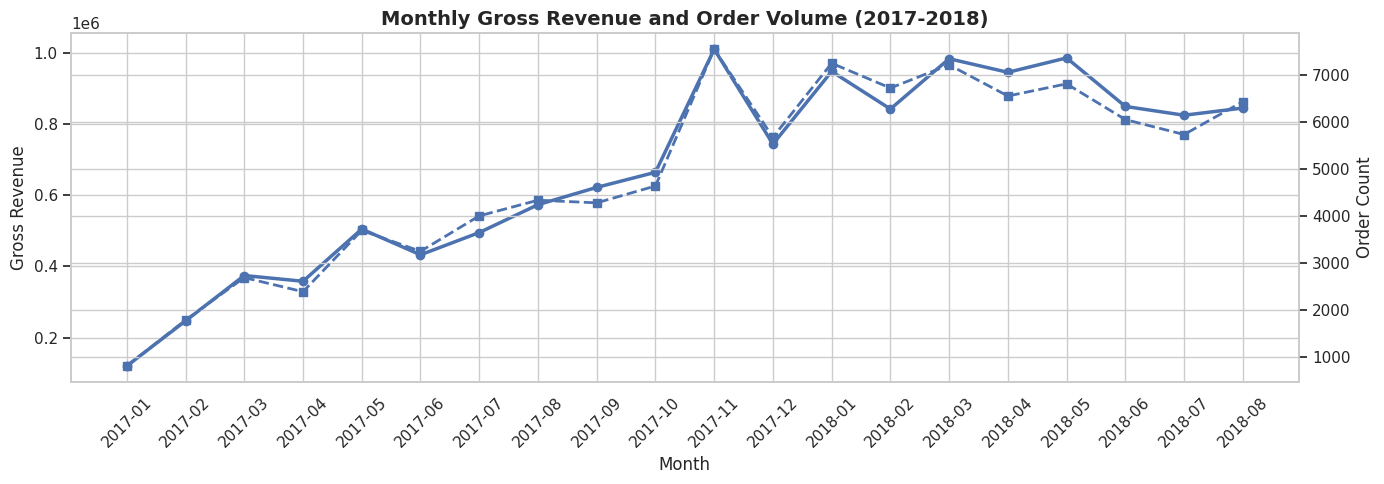

In [81]:
# Configure the plotting environment for the EDA charts.
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Aggregate monthly order count and gross revenue.
monthly_sales = (
    df.groupby(df["order_purchase_timestamp"].dt.to_period("M"))
    .agg(
        total_orders=("order_id", "nunique"),
        total_revenue=("gross_revenue", "sum")
    )
    .reset_index()
)

monthly_sales["month_str"] = monthly_sales["order_purchase_timestamp"].astype(str)

# Keep the complete operating months in the source dataset.
monthly_sales_clean = monthly_sales[
    (monthly_sales["month_str"] >= "2017-01") &
    (monthly_sales["month_str"] <= "2018-08")
]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.set_xlabel("Month")
ax1.set_ylabel("Gross Revenue")
ax1.plot(
    monthly_sales_clean["month_str"],
    monthly_sales_clean["total_revenue"],
    marker="o",
    linewidth=2.5,
    label="Gross Revenue"
)
ax1.tick_params(axis="y")
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel("Order Count")
ax2.plot(
    monthly_sales_clean["month_str"],
    monthly_sales_clean["total_orders"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Order Count"
)
ax2.tick_params(axis="y")

plt.title("Monthly Gross Revenue and Order Volume (2017-2018)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 2. Top & Bottom Product Categories by Revenue

Categories are ranked using observed gross revenue from the order-item prices.

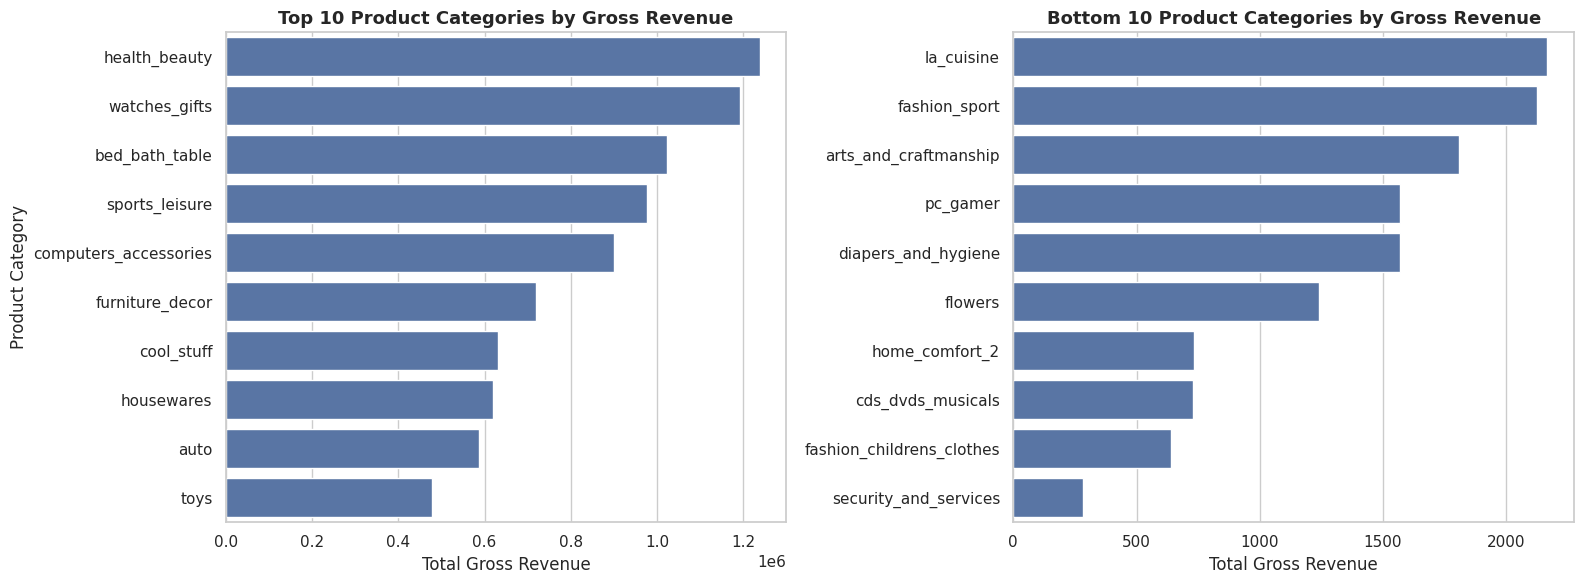

In [82]:
# Aggregate observed gross revenue by product category.
category_revenue = (
    df.groupby("product_category_name_english")["gross_revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top categories by gross revenue.
sns.barplot(
    data=category_revenue.head(10),
    x="gross_revenue",
    y="product_category_name_english",
    ax=ax1
)
ax1.set_title("Top 10 Product Categories by Gross Revenue", fontsize=13, fontweight="bold")
ax1.set_xlabel("Total Gross Revenue")
ax1.set_ylabel("Product Category")

# Bottom categories by gross revenue.
sns.barplot(
    data=category_revenue.tail(10),
    x="gross_revenue",
    y="product_category_name_english",
    ax=ax2
)
ax2.set_title("Bottom 10 Product Categories by Gross Revenue", fontsize=13, fontweight="bold")
ax2.set_xlabel("Total Gross Revenue")
ax2.set_ylabel("")

plt.tight_layout()
plt.show()

## 3. Order Distribution by Day of Week & Hour of Day

These plots show when customers place orders, using the temporal features derived from the purchase timestamp.

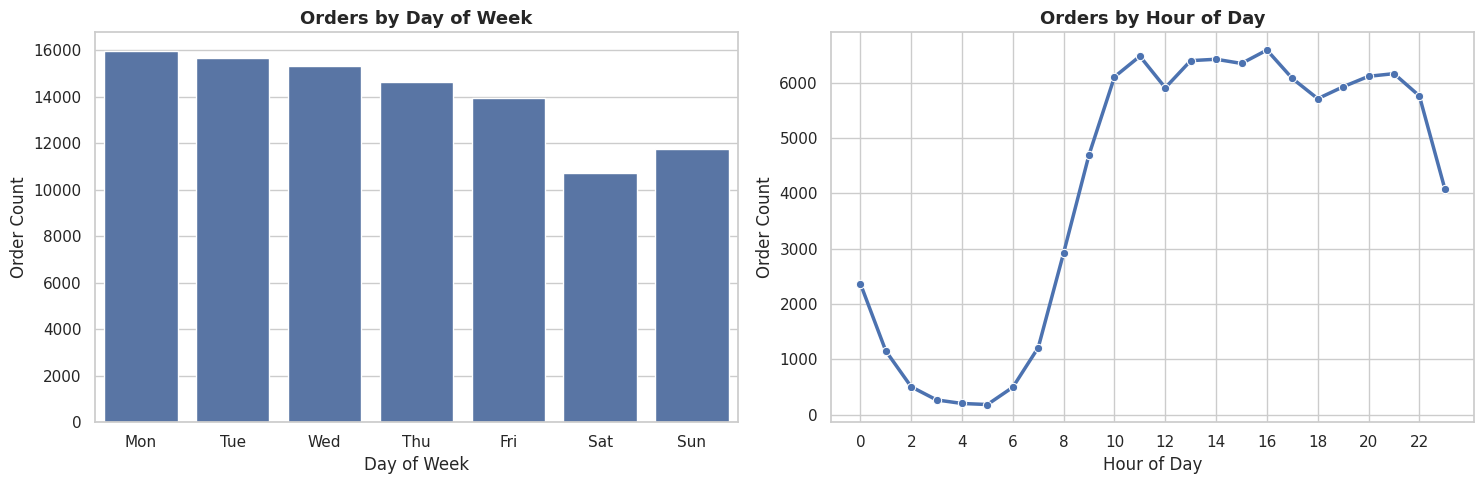

In [83]:
# Compare order volume across days of the week and hours of the day.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_counts = df["order_weekday"].value_counts().reindex(range(7))

sns.barplot(x=day_names, y=dow_counts.values, ax=ax1)
ax1.set_title("Orders by Day of Week", fontsize=13, fontweight="bold")
ax1.set_xlabel("Day of Week")
ax1.set_ylabel("Order Count")

hour_counts = df["order_hour"].value_counts().sort_index()

sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker="o", linewidth=2.5, ax=ax2)
ax2.set_title("Orders by Hour of Day", fontsize=13, fontweight="bold")
ax2.set_xlabel("Hour of Day")
ax2.set_ylabel("Order Count")
ax2.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

## 4. Delivery Delay & Shipping Performance Analysis

The first plot shows the distribution of delivery delay. The second compares late-delivery rates across customer states with a minimum order-count threshold.

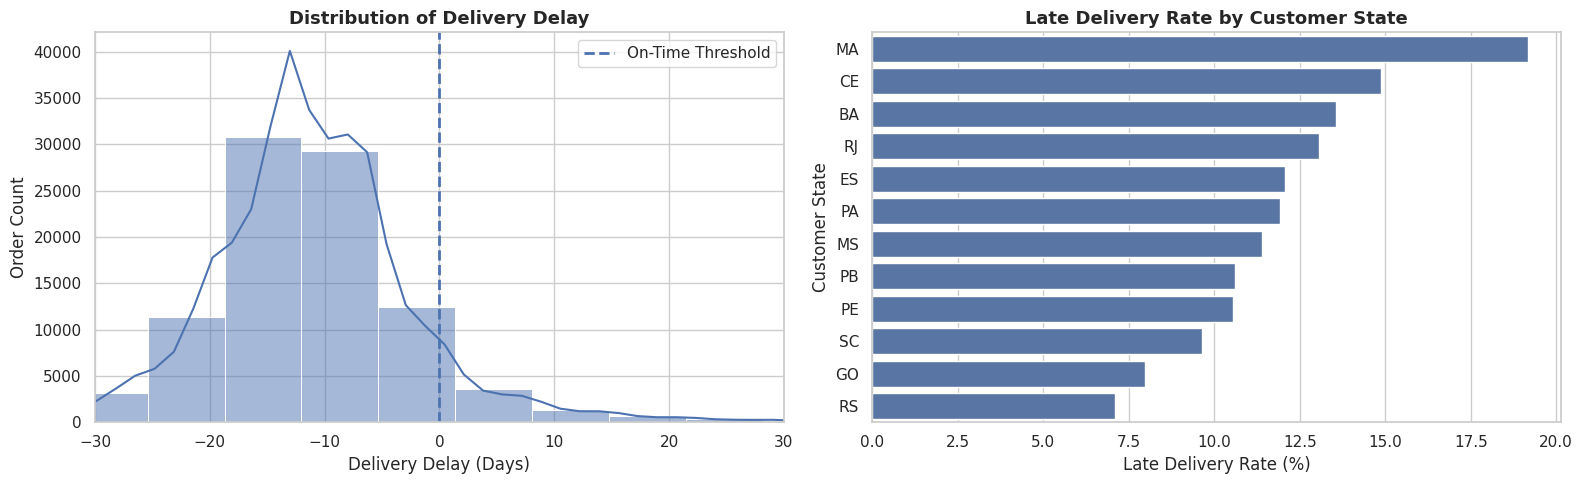

In [84]:
# Examine delivery-delay distribution and late-delivery rates by customer state.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df["delivery_delay"].dropna(), bins=50, kde=True, ax=ax1)
ax1.axvline(0, linestyle="--", linewidth=2, label="On-Time Threshold")
ax1.set_xlim(-30, 30)
ax1.set_title("Distribution of Delivery Delay", fontsize=13, fontweight="bold")
ax1.set_xlabel("Delivery Delay (Days)")
ax1.set_ylabel("Order Count")
ax1.legend()

state_late = (
    df.groupby("customer_state")
    .agg(
        total_orders=("order_id", "count"),
        late_orders=("is_late", "sum")
    )
    .reset_index()
)
state_late["late_rate"] = state_late["late_orders"] / state_late["total_orders"] * 100

state_late_sorted = (
    state_late[state_late["total_orders"] > 500]
    .sort_values("late_rate", ascending=False)
)

sns.barplot(
    data=state_late_sorted.head(12),
    x="late_rate",
    y="customer_state",
    ax=ax2
)
ax2.set_title("Late Delivery Rate by Customer State", fontsize=13, fontweight="bold")
ax2.set_xlabel("Late Delivery Rate (%)")
ax2.set_ylabel("Customer State")

plt.tight_layout()
plt.show()

## 5. Impact of Delivery Delays on Customer Review Scores

This analysis compares the rating distribution with average ratings for orders classified as on-time/early versus late.

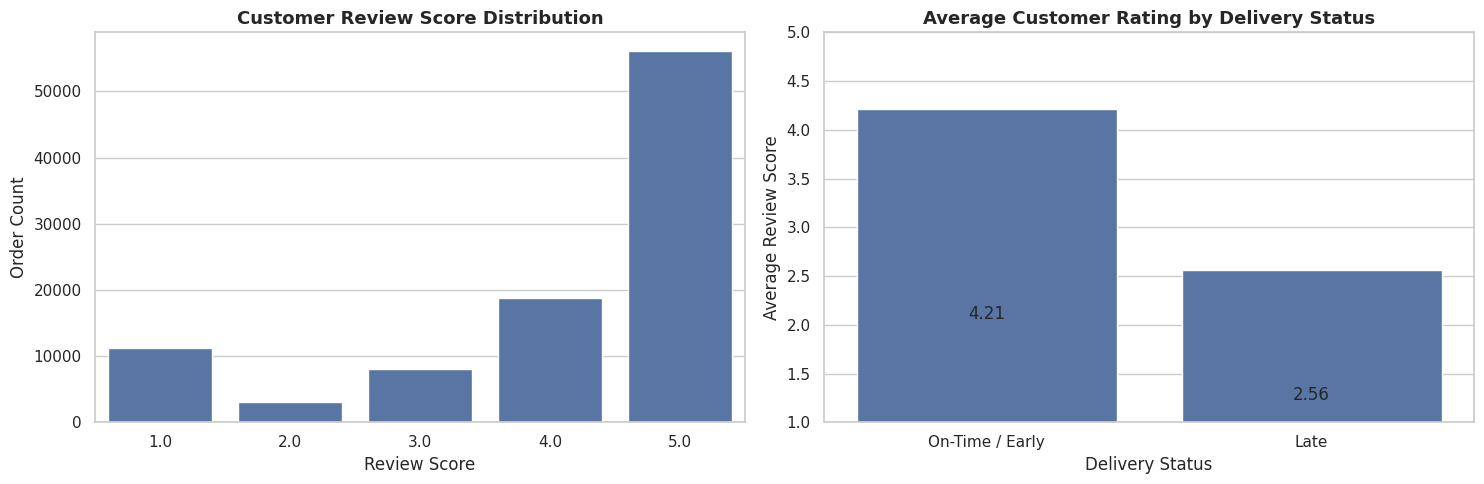

In [85]:
# Compare customer ratings with delivery timeliness.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of review scores.
sns.countplot(data=df, x="review_score", ax=ax1)
ax1.set_title("Customer Review Score Distribution", fontsize=13, fontweight="bold")
ax1.set_xlabel("Review Score")
ax1.set_ylabel("Order Count")

# Average rating by late-delivery status.
rating_by_late = (
    df.dropna(subset=["review_score"])
    .groupby("is_late")["review_score"]
    .mean()
    .reset_index()
)

sns.barplot(data=rating_by_late, x="is_late", y="review_score", ax=ax2)
ax2.set_title("Average Customer Rating by Delivery Status", fontsize=13, fontweight="bold")
ax2.set_xlabel("Delivery Status")
ax2.set_ylabel("Average Review Score")
ax2.set_ylim(1, 5)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["On-Time / Early", "Late"])

for p in ax2.patches:
    ax2.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height() / 2),
        ha="center",
        va="center",
        fontsize=12
    )

plt.tight_layout()
plt.show()

## 6. Payment Methods & Order Value Analysis

The first plot shows payment-method usage. The second shows average payment value by installment count, restricted to orders with up to 12 installments.

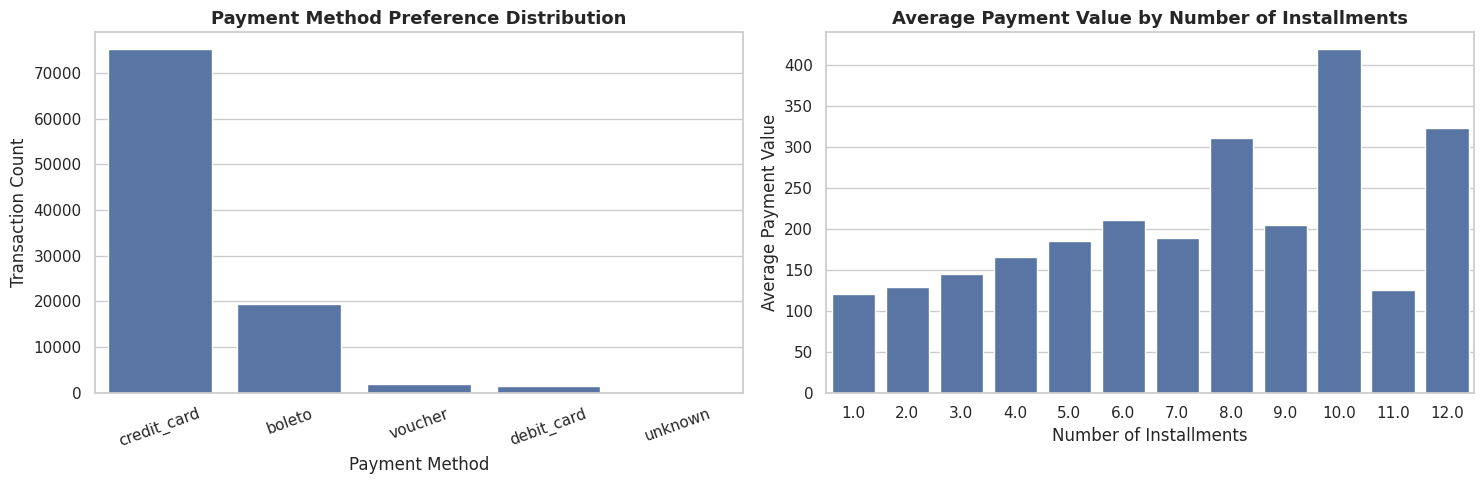

In [86]:
# Explore payment-method usage and payment value by installment count.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

payment_counts = df["payment_type"].fillna("unknown").value_counts()

sns.barplot(x=payment_counts.index, y=payment_counts.values, ax=ax1)
ax1.set_title("Payment Method Preference Distribution", fontsize=13, fontweight="bold")
ax1.set_xlabel("Payment Method")
ax1.set_ylabel("Transaction Count")
ax1.tick_params(axis="x", rotation=20)

installment_data = df[
    df["max_installments"].notna() &
    (df["max_installments"] <= 12)
]

avg_payment_by_installments = (
    installment_data
    .groupby("max_installments")["total_payment"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=avg_payment_by_installments,
    x="max_installments",
    y="total_payment",
    ax=ax2
)
ax2.set_title("Average Payment Value by Number of Installments", fontsize=13, fontweight="bold")
ax2.set_xlabel("Number of Installments")
ax2.set_ylabel("Average Payment Value")

plt.tight_layout()
plt.show()

## 7. Correlation Heatmap of Numerical Features

The heatmap summarizes linear correlations among observed revenue, shipping, delivery, payment, and rating variables.

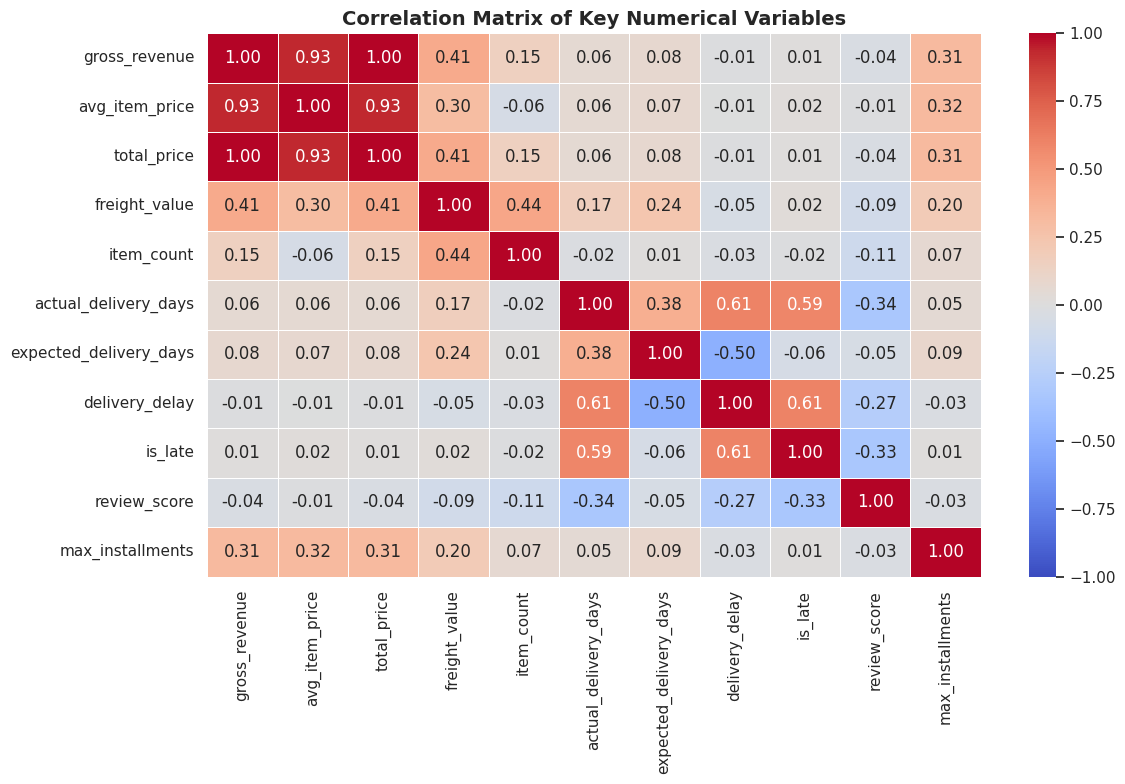

In [87]:
# Select the numerical variables used in the correlation analysis.
corr_cols = [
    "gross_revenue",
    "avg_item_price",
    "total_price",
    "freight_value",
    "item_count",
    "actual_delivery_days",
    "expected_delivery_days",
    "delivery_delay",
    "is_late",
    "review_score",
    "max_installments"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Correlation Matrix of Key Numerical Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## EDA Summary

The EDA covers the main measurable aspects of the current Olist dataset:

- Order volume and observed gross revenue over time.
- Revenue concentration across product categories.
- Order timing by weekday and hour.
- Delivery-delay distribution and late-delivery rates by customer state.
- Customer-rating distribution and the relationship between ratings and late deliveries.
- Payment-method usage and average payment value by installment count.
- Correlations among the final numerical variables.

# Model 3: Customer Rating Prediction (Regression)

In this individual phase, we build, tune, evaluate, and interpret **Model 3: Customer Rating Prediction**.

The goal is to predict the customer rating score (1 to 5 stars) using information available in the order-level dataset and to identify observable factors associated with customer satisfaction.

## <span style="color: #5DADE2;">1. Target Variable Definition & Distribution Check</span>

**Target:** `review_score` (1 to 5 rating).

Rows with missing ratings are excluded because they do not provide a target value for supervised regression.

In [88]:
# Create the Model 3 dataset by keeping only orders with a known customer rating.
df_m3 = df.dropna(subset=["review_score"]).copy()

# Use seller state as a geographical proxy because Olist has no carrier/courier identifier.
df_m3["seller_state_proxy"] = df_m3["seller_state"].fillna("Other")

# Use payment type as the available transaction-channel proxy.
df_m3["payment_type"] = df_m3["payment_type"].fillna("unknown")

print("Total orders with valid ratings:", len(df_m3))
display(df_m3["review_score"].value_counts().sort_index())

Total orders with valid ratings: 97300


review_score
1.0    11257
2.0     3091
3.0     8051
4.0    18766
5.0    56135
Name: count, dtype: int64

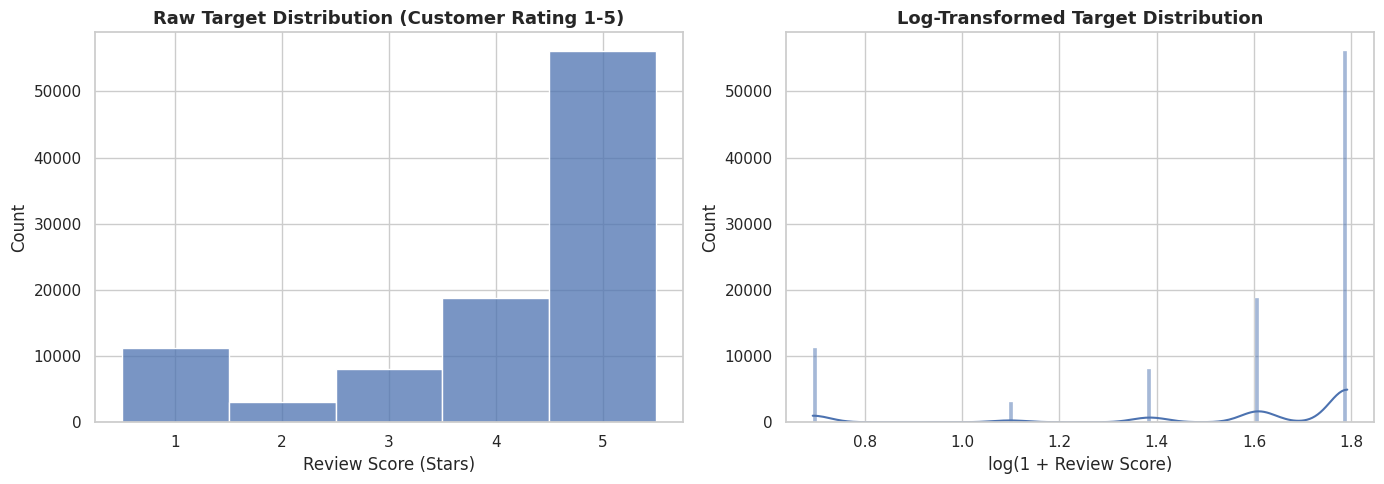

In [89]:
# Compare the observed rating distribution with a log1p-transformed version.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Raw rating distribution.
sns.histplot(df_m3["review_score"], bins=5, discrete=True, ax=ax1)
ax1.set_title("Raw Target Distribution (Customer Rating 1-5)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Review Score (Stars)")
ax1.set_ylabel("Count")

# Log-transformed distribution for visual comparison.
log_review_score = np.log1p(df_m3["review_score"])
sns.histplot(log_review_score, kde=True, ax=ax2)
ax2.set_title("Log-Transformed Target Distribution", fontsize=13, fontweight="bold")
ax2.set_xlabel("log(1 + Review Score)")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.show()

## <span style="color: #5DADE2;">2. Feature Selection & Train/Test Split</span>

**Features used by the final Model 3 dataset:**

- `delivery_delay`: actual delivery duration minus expected delivery duration.
- `product_category_name_english`: translated product category.
- `seller_state_proxy`: seller state used as a geographical logistics proxy because no courier identifier is available.
- `payment_type`: payment method used as the available transaction/channel proxy.
- `avg_item_price`: average item price within the order.
- `freight_value`: total freight value for the order.

The Olist dataset does **not** contain reliable discount, competitor-price, or return-status fields, so those variables are not fabricated or included in the final model.

In [90]:
# Define the final Model 3 feature matrix and target.
features_m3 = [
    "delivery_delay",
    "product_category_name_english",
    "seller_state_proxy",
    "payment_type",
    "avg_item_price",
    "freight_value"
]

X = df_m3[features_m3].copy()
y = df_m3["review_score"].copy()

# Fill missing categorical values with explicit labels.
X["product_category_name_english"] = X["product_category_name_english"].fillna("other")
X["seller_state_proxy"] = X["seller_state_proxy"].fillna("Other")
X["payment_type"] = X["payment_type"].fillna("unknown")

# Fill missing numerical values with simple neutral/median fallbacks.
X["delivery_delay"] = X["delivery_delay"].fillna(0)
X["avg_item_price"] = X["avg_item_price"].fillna(X["avg_item_price"].median())
X["freight_value"] = X["freight_value"].fillna(X["freight_value"].median())

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
display(X.head())

Feature matrix shape: (97300, 6)
Target shape: (97300,)


,delivery_delay,product_category_name_english,seller_state_proxy,payment_type,avg_item_price,freight_value
0,-7.107488,housewares,SP,voucher,29.99,8.72
1,-5.355729,perfumery,SP,boleto,118.70,22.76
2,-17.245498,auto,SP,credit_card,159.90,19.22
3,-12.980069,pet_shop,MG,credit_card,45.00,27.20
4,-9.238171,stationery,SP,credit_card,19.90,8.72


In [91]:
# Split the data before fitting any preprocessing steps.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Group features by preprocessing type.
num_cols = [
    "delivery_delay",
    "avg_item_price",
    "freight_value"
]

cat_cols = [
    "product_category_name_english",
    "seller_state_proxy",
    "payment_type"
]

# Scale numerical variables and one-hot encode categorical variables.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            cat_cols
        )
    ]
)

# Fit transformations on the training data only.
X_train_prep = preprocessor.fit_transform(X_train)

# Apply the fitted transformation to the test data.
X_test_prep = preprocessor.transform(X_test)

print("Preprocessed feature matrix shape:", X_train_prep.shape)

Training set size: 77840 samples
Testing set size: 19460 samples
Preprocessed feature matrix shape: (77840, 106)


## <span style="color: #5DADE2;">3. Model Training & 4-Algorithm Comparison</span>

The final Model 3 comparison includes the four regression algorithms required by the project:

1. **Linear Regression** — simple linear baseline.
2. **Decision Tree Regressor** — non-linear tree-based model.
3. **Random Forest Regressor** — ensemble of decision trees.
4. **KNN Regressor** — distance-based regression model.

Each algorithm is trained on the same preprocessed training data and evaluated on the same held-out test set using MAE, RMSE, and R².

In [ ]:
# Define the four regression algorithms required for Model 3.
algorithms = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=15, n_jobs=-1)
}

comparison_results = []

# Train and evaluate each candidate model on the same test split.
for name, model in algorithms.items():
    model.fit(X_train_prep, y_train)
    preds = model.predict(X_test_prep)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    comparison_results.append({
        "Algorithm": name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R-squared": round(r2, 4)
    })

comparison_df = pd.DataFrame(comparison_results).sort_values("RMSE")
display(comparison_df)

,Algorithm,MAE,RMSE,R-squared
2,Random Forest Regressor,0.8847,1.1494,0.2773
1,Decision Tree Regressor,0.8942,1.1732,0.2469
3,KNN Regressor,0.9328,1.2246,0.1795
0,Linear Regression,0.9873,1.2634,0.1267


## <span style="color: #5DADE2;">4. Hyperparameter Tuning (GridSearchCV)</span>

The best-performing model from the comparison is tuned using **GridSearchCV with 3-fold cross-validation**. The search optimizes the Random Forest parameters below and uses RMSE as the selection criterion.

In [93]:
# Define the Random Forest hyperparameter search space.
param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [10, 15],
    "min_samples_split": [2, 5]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

# Fit the hyperparameter search on the training data only.
grid_search.fit(X_train_prep, y_train)

best_rf_model = grid_search.best_estimator_

# Evaluate the tuned model on the untouched test set.
y_pred_best = best_rf_model.predict(X_test_prep)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("Best Parameters:", grid_search.best_params_)
print(
    f"Tuned Model Performance -> "
    f"MAE: {mae_best:.4f} | RMSE: {rmse_best:.4f} | R²: {r2_best:.4f}"
)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 150}
Tuned Model Performance -> MAE: 0.8858 | RMSE: 1.1492 | R²: 0.2776


## <span style="color: #5DADE2;">5. Final Model Evaluation & Diagnostics Plots</span>

The final evaluation section includes the plots required for regression diagnostics:

1. **Predicted vs Actual Rating** — visualizes prediction accuracy across the rating range.
2. **Residual Plot** — checks the size and pattern of prediction errors.
3. **MAE by Product Category** — identifies categories where the model makes larger errors.
4. **Feature Importance** — ranks the input variables used by the tuned Random Forest.

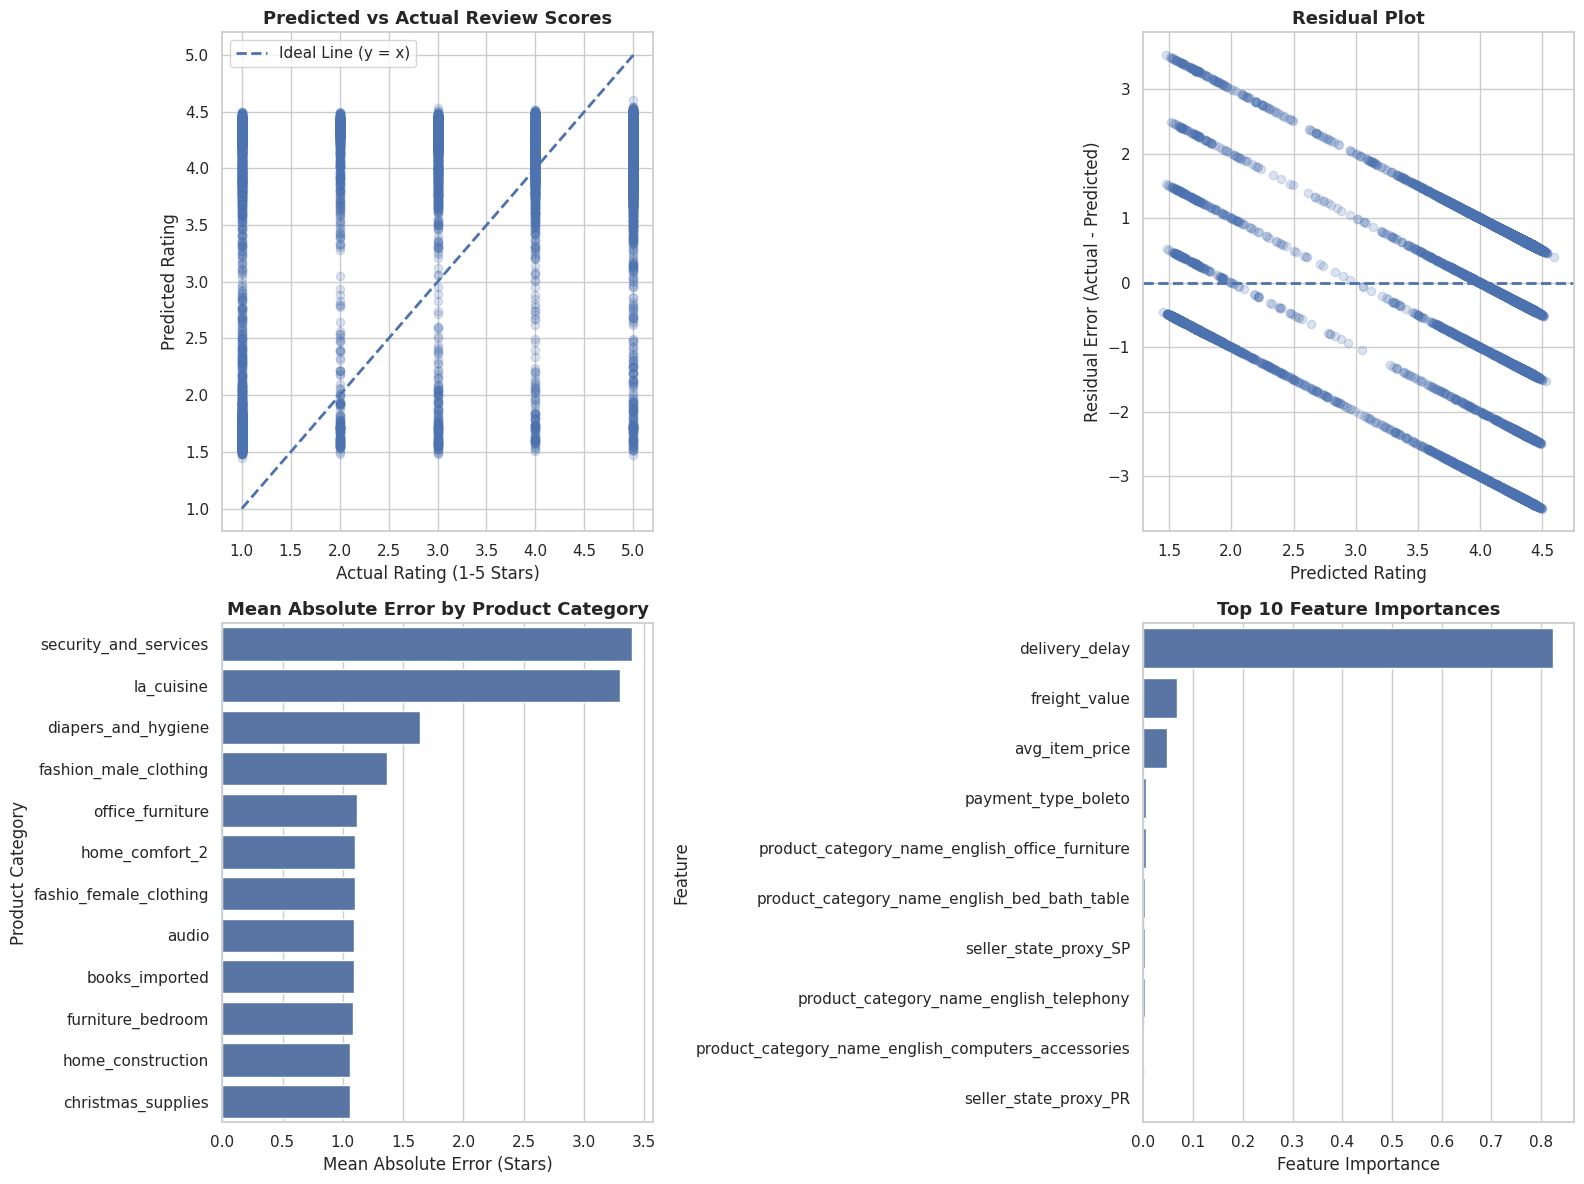

In [94]:
# Create the final diagnostic plots for the tuned Random Forest model.
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Predicted vs actual ratings.
ax1.scatter(y_test, y_pred_best, alpha=0.2)
ax1.plot([1, 5], [1, 5], "--", linewidth=2, label="Ideal Line (y = x)")
ax1.set_title("Predicted vs Actual Review Scores", fontsize=13, fontweight="bold")
ax1.set_xlabel("Actual Rating (1-5 Stars)")
ax1.set_ylabel("Predicted Rating")
ax1.legend()

# 2. Residuals: actual rating minus predicted rating.
residuals = y_test - y_pred_best
ax2.scatter(y_pred_best, residuals, alpha=0.2)
ax2.axhline(0, linestyle="--", linewidth=2)
ax2.set_title("Residual Plot", fontsize=13, fontweight="bold")
ax2.set_xlabel("Predicted Rating")
ax2.set_ylabel("Residual Error (Actual - Predicted)")

# 3. Mean absolute error by product category.
test_results_df = X_test.copy()
test_results_df["actual_rating"] = y_test
test_results_df["pred_rating"] = y_pred_best
test_results_df["abs_error"] = np.abs(y_test - y_pred_best)

cat_error = (
    test_results_df
    .groupby("product_category_name_english")["abs_error"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=cat_error.head(12),
    x="abs_error",
    y="product_category_name_english",
    ax=ax3
)
ax3.set_title("Mean Absolute Error by Product Category", fontsize=13, fontweight="bold")
ax3.set_xlabel("Mean Absolute Error (Stars)")
ax3.set_ylabel("Product Category")

# 4. Random Forest feature importance.
encoded_cat_names = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([num_cols, encoded_cat_names])

importances = best_rf_model.feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": all_feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

sns.barplot(
    data=importance_df.head(10),
    x="Importance",
    y="Feature",
    ax=ax4
)
ax4.set_title("Top 10 Feature Importances", fontsize=13, fontweight="bold")
ax4.set_xlabel("Feature Importance")
ax4.set_ylabel("Feature")

plt.tight_layout()
plt.show()

## <span style="color: #5DADE2;">6. Error Analysis</span>

**Error analysis should be based on the final model outputs above.**

Review the following patterns after running the notebook:

- Which rating levels have the largest residual errors?
- Which product categories have the highest MAE?
- Are errors concentrated among late deliveries or specific seller-state proxies?
- Does the model systematically over-predict or under-predict certain rating ranges?

The conclusions in this section should be written from the actual final results, not copied from the earlier synthetic-feature version of the notebook.

## 📋 Key Findings & Business Insights

### Insight 1 — Delivery Performance
- **What happened?** Report the observed difference in ratings or model errors across delivery-delay groups.
- **ML meaning:** Describe the importance or error pattern associated with `delivery_delay`.
- **Business meaning:** Explain what the result suggests about customer satisfaction.
- **Action / recommendation:** Suggest a realistic operational action.

### Insight 2 — Product Category
- **What happened?** Identify categories with notably higher/lower ratings or prediction errors.
- **ML meaning:** Explain the category-related model behavior.
- **Business meaning:** Connect the pattern to the customer experience.
- **Action / recommendation:** Suggest a category-specific action.

### Insight 3 — Payment or Seller Geography
- **What happened?** Report an observed pattern by payment type or seller-state proxy.
- **ML meaning:** Explain the corresponding model behavior.
- **Business meaning:** Describe the operational implication.
- **Action / recommendation:** Suggest a measurable intervention.

**Do not report exact numerical values here until the final notebook has been re-run after the feature-engineering changes.**

## <span style="color: #5DADE2;">7. Business Recommendations</span>

The recommendations should be derived directly from the final findings.

1. Improve delivery monitoring and proactive communication where delivery delay is associated with lower ratings.
2. Investigate product categories with consistently high prediction error or low ratings.
3. Review seller-state logistics patterns when the geographical proxy shows a persistent performance gap.
4. Use payment behavior only when the EDA shows a meaningful and actionable relationship with order value or customer ratings.

## <span style="color: #5DADE2;">8. Model Limitations</span>

1. **Limited customer-profile information:** the Olist dataset does not provide reliable customer age, so age-based features are not used.
2. **Limited logistics detail:** there is no direct courier/carrier identifier; `seller_state` is used only as a geographical proxy.
3. **Limited pricing context:** reliable discount and competitor-price fields are not available, so those variables are excluded rather than simulated.
4. **Rating imbalance:** the rating distribution is strongly concentrated toward high scores, which may make extreme ratings harder to predict.
5. **Unobserved product-quality factors:** review text and other qualitative causes of dissatisfaction are not used as predictors in this model.

## <span style="color: #5DADE2;">9. Model & Deliverables Export</span>

The cleaned order-level dataset and the final tuned model are exported for submission.

In [ ]:
# Export the final cleaned order-level dataset and tuned Random Forest model.
df.to_csv("Capstone_Clean_Orders.csv", index=False)
joblib.dump(best_rf_model, "best_model.pkl")
comparison_df.to_csv("model_comparison.csv", index=False)

print("Successfully exported Capstone_Clean_Orders.csv, model_comparison.csv and best_model.pkl!")

Successfully exported Capstone_Clean_Orders.csv, model_comparison.csv and best_model.pkl!
